# Sentinel-1 GRD Product: Analysis Mode


In [4]:
import os

import rioxarray
import pystac_client
import numpy as np
import xarray as xr
import dask.array as da
from xcube.core.store import new_data_store
from xcube_resampling.gridmapping import GridMapping
from xcube_resampling import affine_transform_dataset
from xcube_resampling import rectify_dataset
from xcube_resampling.gridmapping import GridMapping
from dask.distributed import Client, LocalCluster
import xrspatial
import matplotlib.pyplot as plt
from resample import resample_reg2irreg
import pyproj 

xr.set_options(display_expand_attrs=False)

cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    memory_limit="8GB",
    dashboard_address="8787",
)
client = Client(cluster)
client.dashboard_link

## Load Sentinel-1 GRD product

In [5]:
path = (
    "data/S1C_IW_GRDH_1SDV_20260331T043117_20260331T043142_007003_00E2E3_7002.zarr"
)

In [6]:
%%time
dt = xr.open_datatree(path, engine="zarr", chunks={})
dt

CPU times: user 348 ms, sys: 139 ms, total: 487 ms
Wall time: 641 ms


<xarray.DataTree>
Group: /
│   Attributes: (2)
├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH
│   │   Attributes: (3)
│   ├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions
│   │   ├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/antenna_pattern
│   │   │       Dimensions:              (azimuth_time: 28, count: 693)
│   │   │       Coordinates:
│   │   │         * azimuth_time         (azimuth_time) datetime64[ns] 224B 2026-03-31T04:31:...
│   │   │         * count                (count) int64 6kB 0 1 2 3 4 5 ... 688 689 690 691 692
│   │   │       Data variables:
│   │   │           elevation_angle      (azimuth_time, count) float32 78kB dask.array<chunksize=(28, 693), meta=np.ndarray>
│   │   │           incidence_angle      (azimuth_time, count) float32 78kB dask.array<chunksize=(28, 693), meta=np.ndarray>
│   │   │           roll                 (azimuth_time) float64 224B dask.array<chunksize=(28,), meta=np.ndarray>
│   │   │           slant_range_time_ap  (azimuth_time, count) float64 155kB dask.array<chunksize=(28, 693), meta=np.ndarray>
│   │   │           swath                (azimuth_time) <U3 336B dask.array<chunksize=(28,), meta=np.ndarray>
│   │   │           terrain_height       (azimuth_time) float64 224B dask.array<chunksize=(28,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/attitude
│   │   │       Dimensions:       (azimuth_time: 25)
│   │   │       Coordinates:
│   │   │         * azimuth_time  (azimuth_time) datetime64[ns] 200B 2026-03-31T04:31:17.9999...
│   │   │       Data variables:
│   │   │           pitch         (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q0            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q1            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q2            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q3            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           roll          (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wx            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wy            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wz            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           yaw           (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/doppler_centroid
│   │   │       Dimensions:                            (azimuth_time: 27, degree: 3)
│   │   │       Coordinates:
│   │   │         * azimuth_time                       (azimuth_time) datetime64[ns] 216B 202...
│   │   │         * degree                             (degree) int64 24B 2 1 0
│   │   │       Data variables:
│   │   │           data_dc_polynomial                 (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
│   │   │           data_dc_rms_error                  (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           data_dc_rms_error_above_threshold  (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_start_time        (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_stop_time         (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           geometry_dc_polynomial             (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
│   │   │           t0                                 (azimuth_time) float64 216

In [7]:
%%time
group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
grd

CPU times: user 12.7 ms, sys: 3.13 ms, total: 15.9 ms
Wall time: 20.1 ms


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

CPU times: user 1.93 s, sys: 2 s, total: 3.94 s
Wall time: 486 ms


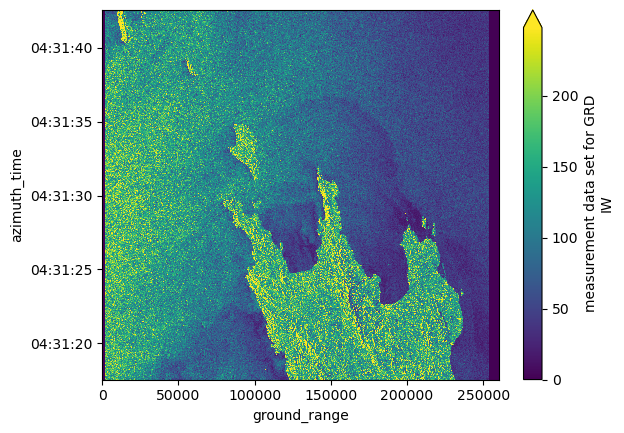

In [9]:
%%time
grd.vv[::20, ::20].plot(robust=True)

## Apply radiometric calibration

In [10]:
%%time
beta_lut = dt[group_VH].quality.calibration.to_dataset()["beta_nought"]
beta_lut

CPU times: user 211 μs, sys: 70 μs, total: 281 μs
Wall time: 284 μs


<xarray.DataArray 'beta_nought' (azimuth_time: 27, ground_range: 651)> Size: 70kB
dask.array<open_dataset-beta_nought, shape=(27, 651), dtype=float32, chunksize=(27, 651), chunktype=numpy.ndarray>
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 216B 2026-03-31T04:31:17.5659...
    line          (azimuth_time) int32 108B dask.array<chunksize=(27,), meta=np.ndarray>
  * ground_range  (ground_range) float64 5kB 0.0 400.0 ... 2.596e+05 2.6e+05
    pixel         (ground_range) int32 3kB dask.array<chunksize=(651,), meta=np.ndarray>
Attributes: (3)

In [11]:
%%time
beta_lut_interp = beta_lut.interp(ground_range=grd.ground_range).chunk(dict(ground_range=2048))
beta_lut_interp = beta_lut_interp.interp(azimuth_time=grd.azimuth_time).chunk(dict(azimuth_time=2048))
beta0 = (grd / beta_lut_interp)**2
beta0

CPU times: user 71.8 ms, sys: 36.4 ms, total: 108 ms
Wall time: 283 ms


<xarray.Dataset> Size: 3GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB 0 1 2 3 ... 25997 25998 25999 26000
Data variables:
    vh            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (3)

CPU times: user 1min 8s, sys: 1min 2s, total: 2min 11s
Wall time: 10.4 s


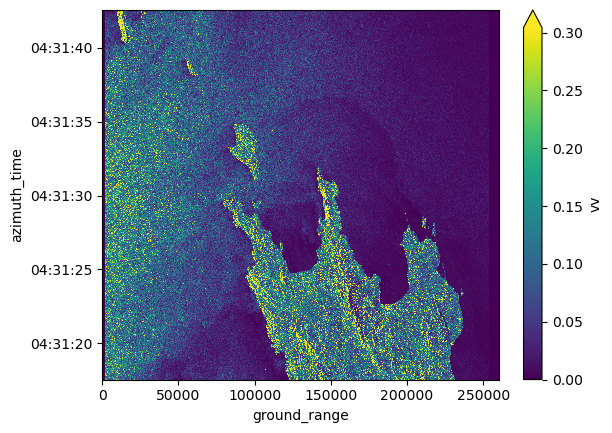

In [12]:
%%time
beta0.vv[::20, ::20].plot(robust=True)

CPU times: user 867 ms, sys: 712 ms, total: 1.58 s
Wall time: 864 ms


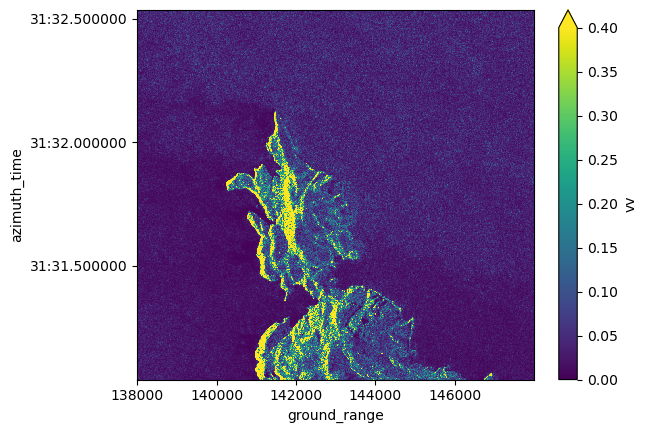

In [24]:
%%time
beta0.vv[9000:10000, 13800:14800].plot(vmin=0, vmax=0.4)

## Add geolocation information

In [11]:
gcps = dt[group_VH].conditions.gcp.to_dataset()
gcps

<xarray.Dataset> Size: 12kB
Dimensions:               (azimuth_time: 10, ground_range: 21)
Coordinates:
  * azimuth_time          (azimuth_time) datetime64[ns] 80B 2026-03-31T04:31:...
    line                  (azimuth_time) int32 40B dask.array<chunksize=(10,), meta=np.ndarray>
  * ground_range          (ground_range) float64 168B 0.0 1.3e+04 ... 2.6e+05
    pixel                 (ground_range) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Data variables:
    azimuth_time_gcp      (azimuth_time, ground_range) datetime64[ns] 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    elevation_angle       (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    height                (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    incidence_angle       (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    latitude              (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    longitude             (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    slant_range_time_gcp  (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>

In [12]:
%%time
gcps = dt[group_VH].conditions.gcp.to_dataset()
gcps = gcps[["latitude", "longitude", "incidence_angle"]]
if gcps.longitude[0, 1] < gcps.longitude[0, 0]:
    gcps = gcps.isel(ground_range=slice(None, None, -1))
gcps

CPU times: user 41.1 ms, sys: 4.83 ms, total: 45.9 ms
Wall time: 86.2 ms


<xarray.Dataset> Size: 5kB
Dimensions:          (azimuth_time: 10, ground_range: 21)
Coordinates:
  * azimuth_time     (azimuth_time) datetime64[ns] 80B 2026-03-31T04:31:17.56...
    line             (azimuth_time) int32 40B dask.array<chunksize=(10,), meta=np.ndarray>
  * ground_range     (ground_range) float64 168B 2.6e+05 2.47e+05 ... 0.0
    pixel            (ground_range) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Data variables:
    latitude         (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    longitude        (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    incidence_angle  (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>

In [13]:
%%time
gcps_interp = gcps.interp(ground_range=grd.ground_range).chunk(dict(ground_range=2048))
gcps_interp = gcps_interp.interp(azimuth_time=grd.azimuth_time).chunk(dict(azimuth_time=2048))
gcps_interp

CPU times: user 29.6 ms, sys: 842 μs, total: 30.4 ms
Wall time: 29.3 ms


<xarray.Dataset> Size: 10GB
Dimensions:          (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time     (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17....
    line             (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range     (ground_range) float64 208kB 0.0 10.0 ... 2.6e+05 2.6e+05
    pixel            (ground_range) float64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    latitude         (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    longitude        (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    incidence_angle  (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

## Get DEM, slope and aspect (precomputed)

In [27]:
%%time
dem = xr.open_dataset("data/dem.zarr", chunks={})
dem = dem.assign_coords({"spatial_ref": dem.spatial_ref})
dem

CPU times: user 3.76 ms, sys: 413 μs, total: 4.17 ms
Wall time: 3.71 ms


<xarray.Dataset> Size: 2GB
Dimensions:      (lat: 10800, lon: 14400)
Coordinates:
  * lat          (lat) float64 86kB 38.0 38.0 38.0 38.0 ... 35.0 35.0 35.0 35.0
  * lon          (lon) float64 115kB 21.0 21.0 21.0 21.0 ... 25.0 25.0 25.0 25.0
    spatial_ref  int64 8B ...
Data variables:
    aspect       (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
    dem          (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
    slope        (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
Attributes: (1)

In [28]:
def convert_dem_to_ecef(dem: xr.Dataset) -> xr.DataArray:
    transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:4978", always_xy=True)

    def transform_block(xx: np.ndarray, yy: np.ndarray, hh: np.ndarray) -> np.ndarray:
        x, y, z = transformer.transform(xx, yy, hh)
        return np.stack([x, y, z], axis=0)

    lon, lat = da.meshgrid(
        da.from_array(dem.lon.values, chunks=dem.dem.data.chunks[1][1]),
        da.from_array(dem.lat.values, chunks=dem.dem.data.chunks[0][1]),
        indexing="xy",
    )

    xyz_transformed = da.map_blocks(
        transform_block,
        lon,
        lat,
        dem.dem.data,
        dtype=np.float32,
        chunks=(3, *dem.dem.data.chunks),
    )

    return xr.DataArray(
        xyz_transformed,
        dims=("axis", "lat", "lon"),
        coords={"lat": dem.lat, "lon": dem.lon, "axis": ["x", "y", "z"]},
    )

In [29]:
dem_ecef = convert_dem_to_ecef(dem)
dem_ecef

<xarray.DataArray 'transform_block-16761653d2f198a31e1ba2df75f53f91' (axis: 3,
                                                                      lat: 10800,
                                                                      lon: 14400)> Size: 2GB
dask.array<transform_block, shape=(3, 10800, 14400), dtype=float32, chunksize=(3, 3600, 3600), chunktype=numpy.ndarray>
Coordinates:
  * axis     (axis) <U1 12B 'x' 'y' 'z'
  * lat      (lat) float64 86kB 38.0 38.0 38.0 38.0 38.0 ... 35.0 35.0 35.0 35.0
  * lon      (lon) float64 115kB 21.0 21.0 21.0 21.0 ... 25.0 25.0 25.0 25.0

## Interpolate slope and aspect

In [31]:
%%time
target_gm = GridMapping.from_coords(gcps_interp.longitude, gcps_interp.latitude, "epsg:4326")
target_gm

CPU times: user 337 ms, sys: 42.7 ms, total: 380 ms
Wall time: 1.45 s


class: **Coords2DGridMapping**
* is_regular: False
* is_j_axis_up: False
* is_lon_360: False
* crs: epsg:4326
* xy_res: (0.000109922, 9.00037e-05)  _estimated_
* xy_bbox: (21.0518211, 35.52715, 24.2434975, 37.4372932)
* ij_bbox: (0, 0, 26001, 16700)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('longitude', 'latitude')
* size: (26001, 16700)
* tile_size: (2048, 2048)

In [32]:
%%time
asslop_interp = resample_reg2irreg(dem, target_gm)
asslop_interp

CPU times: user 4.57 s, sys: 460 ms, total: 5.03 s
Wall time: 13.2 s


<xarray.Dataset> Size: 12GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) float64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    latitude      (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    spatial_ref   int64 8B 0
Data variables:
    aspect        (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    dem           (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    slope         (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (1)

## Calculate azimuth angle

In [15]:
%%time
lat_rad = np.deg2rad(gcps_interp.latitude)

dy = np.gradient(gcps_interp.latitude.data, axis=0)          # degrees
dx = np.gradient(gcps_interp.longitude.data, axis=1) * np.cos(lat_rad)

gcps_interp["viewing_azimuth"] = np.arctan2(dx, dy) + np.pi / 2
gcps_interp

CPU times: user 7.06 ms, sys: 3 μs, total: 7.06 ms
Wall time: 6.98 ms


<xarray.Dataset> Size: 14GB
Dimensions:          (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time     (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17....
    line             (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range     (ground_range) float64 208kB 0.0 10.0 ... 2.6e+05 2.6e+05
    pixel            (ground_range) float64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    latitude         (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    longitude        (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    incidence_angle  (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    viewing_azimuth  (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

## Calcualte gamma nought

In [47]:
%%time
theta_i = np.deg2rad(gcps_interp.incidence_angle)
phi_i = gcps_interp.viewing_azimuth
aspect_rad = np.deg2rad(asslop_interp.aspect)
slope_rad = np.deg2rad(asslop_interp.slope)
cos_theta_lia = (
    np.cos(theta_i) * np.cos(slope_rad) +
    np.sin(theta_i) * np.sin(slope_rad) * np.cos(phi_i - aspect_rad)
)

gamma0 = beta0 / cos_theta_lia
gamma0["dem"] = dem.dem
gamma0

CPU times: user 83.4 ms, sys: 5.68 ms, total: 89.1 ms
Wall time: 136 ms


<xarray.Dataset> Size: 15GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001, lat: 10800,
                   lon: 14400)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB 0 1 2 3 ... 25997 25998 25999 26000
    longitude     (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    latitude      (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
  * lat           (lat) float64 86kB 38.0 38.0 38.0 38.0 ... 35.0 35.0 35.0 35.0
  * lon           (lon) float64 115kB 21.0 21.0 21.0 21.0 ... 25.0 25.0 25.0
    spatial_ref   int64 8B 0
Data variables:
    vh            (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    dem           (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
Attributes: (3)

CPU times: user 10.2 s, sys: 1.05 s, total: 11.3 s
Wall time: 27 s


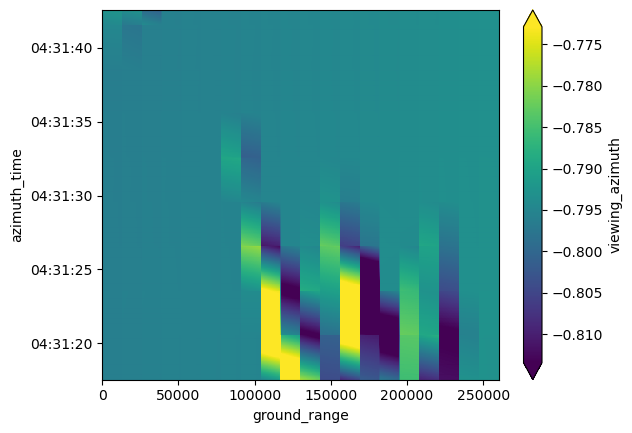

In [48]:
%%time
phi_i[::20, ::20].plot(robust=True)

CPU times: user 36.9 s, sys: 3.94 s, total: 40.9 s
Wall time: 1min 52s


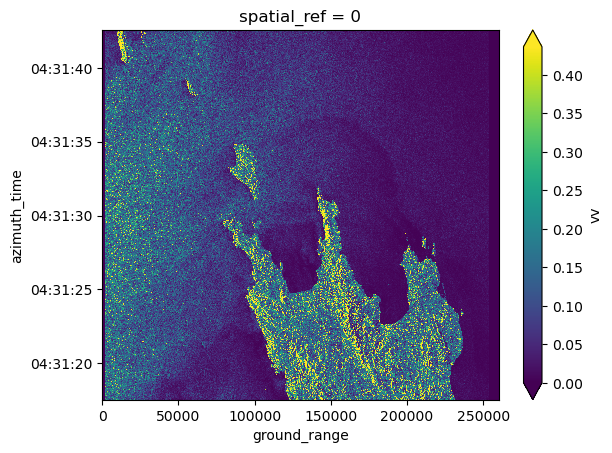

In [49]:
%%time
gamma0.vv[::20, ::20].plot(robust=True)

## Apply geometric terrain correction

In [14]:
%%time
root = dt["/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV"]

orbit = root["conditions/orbit"].to_dataset()
orbit

CPU times: user 73 μs, sys: 40 μs, total: 113 μs
Wall time: 116 μs


<xarray.Dataset> Size: 964B
Dimensions:       (azimuth_time: 17, axis: 3)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 136B 2026-03-31T04:30:11.5896...
  * axis          (axis) <U1 12B 'x' 'y' 'z'
Data variables:
    position      (azimuth_time, axis) float64 408B dask.array<chunksize=(17, 3), meta=np.ndarray>
    velocity      (azimuth_time, axis) float64 408B dask.array<chunksize=(17, 3), meta=np.ndarray>

In [22]:
S_TO_NS = 10**9

def azimuth_time_to_orbit_time(
    azimuth_time: xr.DataArray, epoch: np.datetime64
) -> xr.DataArray:
    orbit_time = (azimuth_time - epoch) / np.timedelta64(S_TO_NS, "ns")
    return orbit_time.rename("orbit_time")


def fit_orbit(
    orbit: xr.Dataset, time_dim: str = "azimuth_time", deg: int = 5
) -> xr.Dataset:
    time = orbit.coords[time_dim]
    epoch = time.values[0] + (time.values[-1] - time.values[0]) / 2
    interval = (time.values[0], time.values[-1])

    orbit_time = azimuth_time_to_orbit_time(time, epoch)
    orbit = orbit.assign_coords({time_dim: orbit_time})
    polyfit_orbit = orbit.polyfit(dim=time_dim, deg=deg)
    polyfit_orbit.attrs["epoch"] = epoch
    polyfit_orbit.attrs["interval"] = interval

    return polyfit_orbit

In [23]:
polyfit_orbit = fit_orbit(dt["S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV/conditions/orbit"].to_dataset())
polyfit_orbit

<xarray.Dataset> Size: 348B
Dimensions:                        (degree: 6, axis: 3)
Coordinates:
  * degree                         (degree) int64 48B 5 4 3 2 1 0
  * axis                           (axis) <U1 12B 'x' 'y' 'z'
Data variables:
    position_polyfit_coefficients  (degree, axis) float64 144B dask.array<chunksize=(6, 3), meta=np.ndarray>
    velocity_polyfit_coefficients  (degree, axis) float64 144B dask.array<chunksize=(6, 3), meta=np.ndarray>
Attributes: (2)

In [26]:
xr.polyval(grd.azimuth_time, polyfit_orbit.position_polyfit_coefficients)

<xarray.DataArray (azimuth_time: 16700, axis: 3)> Size: 401kB
dask.array<add, shape=(16700, 3), dtype=float64, chunksize=(16700, 3), chunktype=numpy.ndarray>
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * axis          (axis) <U1 12B 'x' 'y' 'z'

In [104]:
%%time
doppler = root["conditions/doppler_centroid"].to_dataset()
doppler

CPU times: user 120 μs, sys: 20 μs, total: 140 μs
Wall time: 144 μs


<xarray.Dataset> Size: 1kB
Dimensions:                            (azimuth_time: 27, degree: 3)
Coordinates:
  * azimuth_time                       (azimuth_time) datetime64[ns] 216B 202...
  * degree                             (degree) int64 24B 2 1 0
Data variables:
    data_dc_polynomial                 (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
    data_dc_rms_error                  (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
    data_dc_rms_error_above_threshold  (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
    fine_dce_azimuth_start_time        (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
    fine_dce_azimuth_stop_time         (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
    geometry_dc_polynomial             (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
    t0                                 (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>

In [105]:
%%time
orbit_interp = orbit.interp(azimuth_time=gamma0.azimuth_time).chunk(dict(azimuth_time=2048))
sat_pos = orbit_interp.position.values
sat_vel = orbit_interp.velocity.values
sat_pos

CPU times: user 70.4 ms, sys: 4.01 ms, total: 74.4 ms
Wall time: 147 ms


array([[5028219.29304734, 2702095.75089204, 4172741.17234378],
       [5028226.29749299, 2702096.55923499, 4172732.25495867],
       [5028233.30193863, 2702097.36757794, 4172723.33757357],
       ...,
       [5143331.18547592, 2714372.11765421, 4022309.46552514],
       [5143337.93666196, 2714372.75949543, 4022300.34076316],
       [5143344.69235781, 2714373.4017654 , 4022291.20990583]],
      shape=(16700, 3))

In [116]:
%%time
transformer = pyproj.Transformer.from_crs(
    "EPSG:4326", "EPSG:4978", always_xy=True
)
x, y, z = transformer.transform(gamma0.longitude[:100, :100].values, gamma0.latitude[:100, :100].values, gamma0.dem[:100, :100].values)
np.stack([x, y, z])

CPU times: user 141 ms, sys: 17.5 ms, total: 159 ms
Wall time: 943 ms


array([[[4648327.02227847, 4648330.02626172, 4648333.03022552, ...,
         4648618.31807192, 4648621.32016804, 4648624.3222447 ],
        [4648333.30669703, 4648336.31067888, 4648339.31464128, ...,
         4648624.60235466, 4648627.60444938, 4648630.60652465],
        [4648339.59110529, 4648342.59508574, 4648345.59904673, ...,
         4648630.8866271 , 4648633.88872042, 4648636.89079429],
        ...,
        [4648936.57968724, 4648939.58353447, 4648942.58736226, ...,
         4649227.86229811, 4649230.86425844, 4649233.86619932],
        [4648942.86310613, 4648945.86695197, 4648948.87077835, ...,
         4649234.14558102, 4649237.14753995, 4649240.14947943],
        [4648949.14651472, 4648952.15035916, 4648955.15418413, ...,
         4649240.42885362, 4649243.43081115, 4649246.43274923]],

       [[2093278.72475947, 2093269.30340521, 2093259.88204696, ...,
         2092364.83483893, 2092355.41309813, 2092345.99135334],
        [2093279.4247006 , 2093270.0033461 , 2093260.58198761

In [117]:
gamma0.longitude.data.chunks

((2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 316),
 (2048,
  2048,
  2048,
  2048,
  2048,
  2048,
  2048,
  2048,
  2048,
  2048,
  2048,
  2048,
  1425))

In [118]:
%%time
transformer = pyproj.Transformer.from_crs(
    "EPSG:4326", "EPSG:4978", always_xy=True
)

def transform_block(
    xx: np.ndarray, yy: np.ndarray, hh: np.ndarray
) -> np.ndarray:
    x, y, z = transformer.transform(xx, yy, hh)
    return np.stack([x, y, z], axis=0)

xyz_transformed = da.map_blocks(
    transform_block,
    gamma0.longitude.data,
    gamma0.latitude.data,
    gamma0.dem.data,
    dtype=np.float32,
    chunks=(3, *gamma0.longitude.data.chunks),
)
x = xyz_transformed[0]
y = xyz_transformed[1]
z = xyz_transformed[2]
x

CPU times: user 5.07 ms, sys: 842 μs, total: 5.91 ms
Wall time: 5.26 ms


dask.array<getitem, shape=(16700, 26001), dtype=float32, chunksize=(2048, 2048), chunktype=numpy.ndarray>

Find closest azimuth index

In [111]:
%%time
# vector from satellite to ground
rx = x[None, :, :] - sat_pos[:, 0][:, None, None]
ry = y[None, :, :] - sat_pos[:, 1][:, None, None]
rz = z[None, :, :] - sat_pos[:, 2][:, None, None]

# dot product with satellite velocity
doppler = (
    rx * sat_vel[:, 0][:, None, None] + 
    ry * sat_vel[:, 1][:, None, None] + 
    rz * sat_vel[:, 2][:, None, None]
)
doppler

CPU times: user 8.77 ms, sys: 786 μs, total: 9.56 ms
Wall time: 8.95 ms


dask.array<add, shape=(16700, 16700, 26001), dtype=float64, chunksize=(16700, 2048, 2048), chunktype=numpy.ndarray>

In [120]:
x[0, 0].compute()

ValueError: Shapes do not align {'.1': {9, 3}, '.0': {4, 13}}

In [112]:
doppler[0, 0, 0].compute()

ValueError: Shapes do not align {'.1': {9, 3}, '.0': {4, 13}}

In [109]:
az_idxs = da.argmin(doppler, axis=0)
az_idxs

dask.array<arg_agg-aggregate, shape=(16700, 26001), dtype=int64, chunksize=(2048, 2048), chunktype=numpy.ndarray>

In [110]:
%%time
az_idxs[:4096, :4096].compute()

CPU times: user 50.2 ms, sys: 804 μs, total: 51 ms
Wall time: 49.6 ms


ValueError: Shapes do not align {'.1': {9, 3}, '.0': {4, 13}}

In [ ]:
%%time
az_idx = np.argmin(
    (sat_x.values[:, None, None] - x)**2 +
    (sat_y.values[:, None, None] - y)**2 +
    (sat_z.values[:, None, None] - z)**2,
    axis=0
)

In [ ]:
def compute_range(x, y, z, sat_x, sat_y, sat_z):
    return np.sqrt(
        (x - sat_x)**2 +
        (y - sat_y)**2 +
        (z - sat_z)**2
    )

In [34]:
dt.groups

('/',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/measurements',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/quality',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV/conditions',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV/measurements',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VV/quality',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/antenna_pattern',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/attitude',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/doppler_centroid',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/gcp',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/orbit',
 '/S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/quality/calibration',
 '/S01SIWGRD_202603

In [35]:
dt["S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/attitude"].to_dataset()

<xarray.Dataset> Size: 2kB
Dimensions:       (azimuth_time: 25)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 200B 2026-03-31T04:31:17.9999...
Data variables:
    pitch         (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
    q0            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
    q1            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
    q2            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
    q3            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
    roll          (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
    wx            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
    wy            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
    wz            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
    yaw           (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>

In [36]:
dt["S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/doppler_centroid"].to_dataset()

<xarray.Dataset> Size: 1kB
Dimensions:                            (azimuth_time: 27, degree: 3)
Coordinates:
  * azimuth_time                       (azimuth_time) datetime64[ns] 216B 202...
  * degree                             (degree) int64 24B 2 1 0
Data variables:
    data_dc_polynomial                 (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
    data_dc_rms_error                  (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
    data_dc_rms_error_above_threshold  (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
    fine_dce_azimuth_start_time        (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
    fine_dce_azimuth_stop_time         (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
    geometry_dc_polynomial             (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
    t0                                 (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>

In [37]:
dt["S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/orbit"].to_dataset()

<xarray.Dataset> Size: 964B
Dimensions:       (azimuth_time: 17, axis: 3)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 136B 2026-03-31T04:30:11.5896...
  * axis          (axis) <U1 12B 'x' 'y' 'z'
Data variables:
    position      (azimuth_time, axis) float64 408B dask.array<chunksize=(17, 3), meta=np.ndarray>
    velocity      (azimuth_time, axis) float64 408B dask.array<chunksize=(17, 3), meta=np.ndarray>

In [39]:
dt["S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/orbit"].to_dataset().position.values

array([[4708123.449713, 2658671.369667, 4555539.415631],
       [4758138.684942, 2666299.587508, 4498921.498465],
       [4807631.419548, 2673556.360952, 4441795.551232],
       [4856595.550369, 2680441.635912, 4384168.013499],
       [4905025.033651, 2686955.408976, 4326045.382096],
       [4952913.885859, 2693097.727342, 4267434.210316],
       [5000256.184435, 2698868.688716, 4208341.107122],
       [5047046.068523, 2704268.441199, 4148772.736348],
       [5093277.739684, 2709297.183158, 4088735.815892],
       [5138945.462593, 2713955.163108, 4028237.116927],
       [5184043.56573 , 2718242.679586, 3967283.463124],
       [5228566.442041, 2722160.081004, 3905881.72988 ],
       [5272508.549599, 2725707.765491, 3844038.843554],
       [5315864.412265, 2728886.180744, 3781761.78072 ],
       [5358628.620387, 2731695.823893, 3719057.567452],
       [5400795.831453, 2734137.241339, 3655933.278671],
       [5442360.770843, 2736211.028648, 3592396.037338]])

## Apply rectification

In [29]:
%%time
grd_rect = rectify_dataset(gamma0, interp_methods="nearest", tile_size=2048)
grd_rect

CPU times: user 55.8 s, sys: 2.24 s, total: 58 s
Wall time: 1min 21s


<xarray.Dataset> Size: 10GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001, lon: 29036,
                   lat: 21223)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB 0 1 2 3 ... 25997 25998 25999 26000
  * lon           (lon) float64 232kB 21.05 21.05 21.05 ... 24.24 24.24 24.24
  * lat           (lat) float64 170kB 37.44 37.44 37.44 ... 35.53 35.53 35.53
    spatial_ref   int64 8B 0
Data variables:
    vh            (lat, lon) float64 5GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (lat, lon) float64 5GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (3)

In [ ]:
%%time
grd_rect = grd_rect.drop_vars(
    ["azimuth_time", "ground_range", "line", "pixel"]
)
grd_rect

In [ ]:
%%time
store = new_data_store("file", root="data")

In [ ]:
%%time
store.write_data(
    grd_rect.isel(lat=slice(0, 8192), lon=slice(0, 8192)),
    "sen1_rectified_sub.zarr",
    replace=True
)

In [ ]:
%%time
ds = store.open_data("sen1_rectified_sub.zarr")
ds

In [ ]:
%%time
ds.vv[::5, ::5].plot(vmax=300)